# Assessing a Structure-Derived HADHA–ENO1 Hypothesis Using Public Bioactivity Data

## 1. Project Overview

This notebook asks whether publicly available ligand bioactivity data are broadly consistent with an earlier structure-based hypothesis, in which HADHA appeared more compatible than ENO1 for lipophilic madecassic-acid-like scaffolds.

Using ChEMBL-derived ligand data, RDKit descriptors, molecular fingerprints, and simple baseline models, the notebook examines two questions: whether ligand-level properties differ across targets, and whether the available public data are sufficient for cautious modelling.

The aim is not independent target validation, but an exploratory follow-up using public bioactivity data.

## 2. Biological Motivation

In earlier dissertation work, HADHA and ENO1 were both considered metabolically relevant proteins in hepatocellular carcinoma. HADHA appeared to offer a larger and more hydrophobic binding environment for madecassic-acid-like scaffolds, whereas ENO1 appeared less compatible with this ligand class in the structural comparison.

ENO1 was still retained in this follow-up because it remained biologically relevant in the broader liver-cancer literature[1] and provided a useful contrast target.

This notebook therefore uses public ligand data as a secondary check on an earlier structural interpretation, rather than as a validation study on its own.

## 3. Data Sources and Target Selection

Three targets were examined: HADHA, ENO1, and ABL1. HADHA and ENO1 were chosen because they were directly relevant to the earlier structural comparison, while ABL1 was included as a positive-control target with a larger public bioactivity dataset.

HADHA was retained despite its sparse public ligand data because it remained central to the original biological question. ABL1 serves as a practical reference point for how the same workflow behaves when a larger ligand set is available.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

In [2]:
sns.set(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

## 4. Workflow Summary

The workflow consisted of four steps: loading public bioactivity records, curating the datasets, comparing curated ligands with a small set of RDKit descriptors, and applying baseline fingerprint-based modelling.

The results were then interpreted in light of dataset size imbalance and the limits of ligand-based analysis.

## 5. Helper Functions

The following helper functions are used for fingerprint generation, descriptor calculation, dataset curation, and repeated cross-validation.

A simple baseline model was chosen because the purpose here is not model optimisation, but a basic check of whether the available data are sufficient for modelling.

In [3]:
def get_fingerprint(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            generator = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
            fp = generator.GetFingerprint(mol)
            return np.array(fp)
    except:
        return None
    return None


def calculate_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return pd.Series({
                "MolWt": Descriptors.MolWt(mol),
                "LogP": Descriptors.MolLogP(mol),
                "TPSA": Descriptors.TPSA(mol),
                "HBD": Descriptors.NumHDonors(mol),
                "HBA": Descriptors.NumHAcceptors(mol)
            })
    except:
        pass
    return pd.Series({
        "MolWt": np.nan,
        "LogP": np.nan,
        "TPSA": np.nan,
        "HBD": np.nan,
        "HBA": np.nan
    })


def curate_bioactivity_df(df, target_name):
    df = df.copy()
    initial_n = len(df)

    df = df.dropna(subset=["Standard Value", "Smiles"])
    df["Standard Value"] = pd.to_numeric(df["Standard Value"], errors="coerce")
    df = df.dropna(subset=["Standard Value"])
    after_numeric_n = len(df)

    df["Fingerprint"] = df["Smiles"].apply(get_fingerprint)
    df = df.dropna(subset=["Fingerprint"])
    final_n = len(df)

    audit = {
        "Target": target_name,
        "Initial ChEMBL records": initial_n,
        "After numeric Standard Value filter": after_numeric_n,
        "Final usable compounds": final_n
    }

    return df, audit


def evaluate_model_cv(X, y, model=None, n_splits=5, n_repeats=10, random_state=42):
    if model is None:
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            class_weight="balanced"
        )

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    scoring = {
        "accuracy": "accuracy",
        "roc_auc": "roc_auc"
    }

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results = {
        "accuracy_mean": np.mean(scores["test_accuracy"]),
        "accuracy_std": np.std(scores["test_accuracy"]),
        "roc_auc_mean": np.mean(scores["test_roc_auc"]),
        "roc_auc_std": np.std(scores["test_roc_auc"]),
        "n_evaluations": len(scores["test_accuracy"])
    }

    return results, scores

## 6. Load Bioactivity Data

In [4]:
hadha_filename = "data/HADHA_bioactivity_data.csv"
eno1_filename = "data/ENO1_bioactivity_data.csv"
abl1_filename = "data/ABL1_bioactivity_data.csv"

df_hadha_raw = pd.read_csv(hadha_filename, sep=";")
df_eno1_raw = pd.read_csv(eno1_filename, sep=";")
df_abl1_raw = pd.read_csv(abl1_filename, sep=";")

df_hadha_raw["Target"] = "HADHA"
df_eno1_raw["Target"] = "ENO1"
df_abl1_raw["Target"] = "ABL1"

## 7. Data Curation

Before descriptor analysis and modelling, records were filtered to retain only entries that could support downstream cheminformatics analysis. Records were excluded if they lacked a usable standard activity value, if the value could not be converted to numeric format, or if no valid molecular fingerprint could be generated from the associated SMILES string.

In [5]:
df_hadha, audit_hadha = curate_bioactivity_df(df_hadha_raw, "HADHA")
df_eno1, audit_eno1 = curate_bioactivity_df(df_eno1_raw, "ENO1")
df_abl1, audit_abl1 = curate_bioactivity_df(df_abl1_raw, "ABL1")

audit_df = pd.DataFrame([audit_hadha, audit_eno1, audit_abl1])
audit_df

,Target,Initial ChEMBL records,After numeric Standard Value filter,Final usable compounds
0,HADHA,7,4,4
1,ENO1,39,36,36
2,ABL1,215,174,174


The curation audit shows a marked difference in usable dataset size across the three targets. HADHA remains very small after filtering, whereas ENO1 and especially ABL1 retain more compounds for downstream analysis.

## 8. Descriptor Analysis of Curated Ligands

To compare the known ligand chemistry associated with each target, a small panel of RDKit descriptors was calculated from curated SMILES strings. Particular attention was paid to LogP, because the earlier structure-derived hypothesis suggested that HADHA may favour a more lipophilic ligand environment than ENO1.

To avoid overcounting repeated records of the same structure, descriptor analysis was performed on unique SMILES entries only. Because the HADHA dataset contains very few unique compounds, individual compound values are shown alongside the boxplots to make the data more transparent.

In [6]:
df_hadha_desc = df_hadha.drop_duplicates(subset=["Smiles"]).copy()
df_eno1_desc = df_eno1.drop_duplicates(subset=["Smiles"]).copy()
df_abl1_desc = df_abl1.drop_duplicates(subset=["Smiles"]).copy()

desc_hadha = df_hadha_desc["Smiles"].apply(calculate_descriptors)
desc_hadha["Target"] = "HADHA"

desc_eno1 = df_eno1_desc["Smiles"].apply(calculate_descriptors)
desc_eno1["Target"] = "ENO1"

desc_abl1 = df_abl1_desc["Smiles"].apply(calculate_descriptors)
desc_abl1["Target"] = "ABL1"

descriptor_df = pd.concat([desc_hadha, desc_eno1, desc_abl1], ignore_index=True)

descriptor_df["Target"].value_counts()

Target
ABL1     122
ENO1      15
HADHA      2
Name: count, dtype: int64

Unique structures available for descriptor analysis remained highly uneven across targets (HADHA: 2, ENO1: 15, ABL1: 122). This should be kept in mind when interpreting all visual comparisons below.

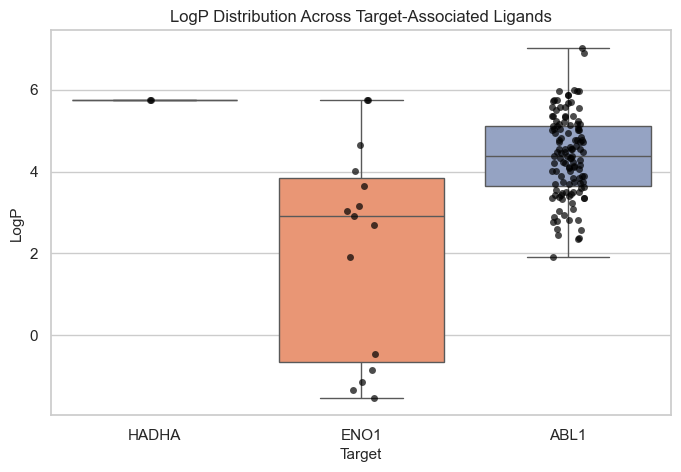

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=descriptor_df, x="Target", y="LogP", palette="Set2")
sns.stripplot(data=descriptor_df, x="Target", y="LogP", color="black", size=5, jitter=0.08, alpha=0.7)

plt.title("LogP Distribution Across Target-Associated Ligands")
plt.ylabel("LogP")
plt.xlabel("Target")
plt.show()

Across the curated set, the HADHA compounds that remained after filtering sit in a highly lipophilic range. Although the sample is too small for strong comparison, this pattern is consistent with the earlier structural view that HADHA may better accommodate lipophilic madecassic-acid-like ligands than ENO1.

In [8]:
descriptor_df[descriptor_df["Target"] == "HADHA"][["Target", "LogP", "MolWt"]].reset_index(drop=True)

,Target,LogP,MolWt
0,HADHA,5.74842,503.488
1,HADHA,5.74842,503.488


For HADHA, only a very small number of unique compounds remained after curation, and their LogP values clustered within a narrow, highly lipophilic range. This limited spread explains why the HADHA boxplot appears visually compressed. For this reason, the HADHA descriptor results should be read as illustrative only.

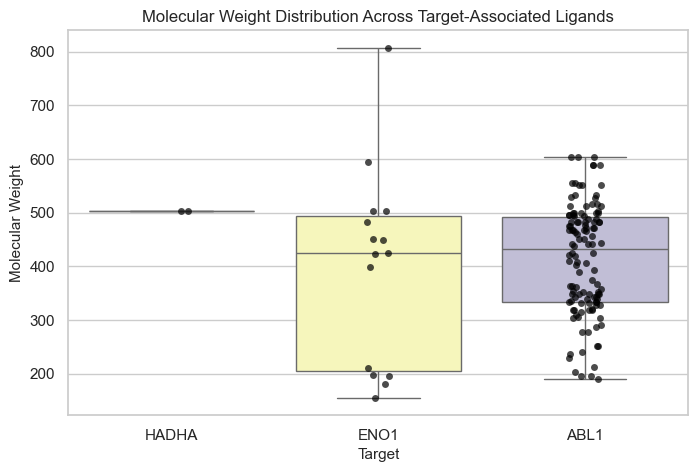

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=descriptor_df, x="Target", y="MolWt", palette="Set3")
sns.stripplot(data=descriptor_df, x="Target", y="MolWt", color="black", size=5, jitter=0.08, alpha=0.7)

plt.title("Molecular Weight Distribution Across Target-Associated Ligands")
plt.ylabel("Molecular Weight")
plt.xlabel("Target")
plt.show()

Molecular weight shows broader differences in overall ligand size and bulk across the three target-associated sets. In this notebook, it is used as a secondary descriptor that adds context to the LogP comparison, rather than as a main basis for biological interpretation.

Taken together, these descriptor plots are best read as qualitative context rather than formal evidence. Their value here is to show whether the limited ligand-level patterns are broadly compatible with the earlier structural interpretation.

## 9. Baseline Fingerprint Modelling

To complement descriptor analysis, molecules were represented using Morgan fingerprints and analysed with a simple baseline Random Forest classifier under repeated stratified cross-validation.

This section is not intended to predict continuous bioactivity values such as potency. Instead, it asks a simpler question: based on molecular fingerprints, can compounds associated with one target be distinguished from compounds associated with the others?

The purpose is therefore not model optimisation, but to assess whether the currently available public datasets are sufficient to support this kind of baseline modelling.

### HADHA

HADHA was analysed first because it is central to the original question. However, the curated HADHA set is too small for reliable repeated stratified cross-validation, so this step functions mainly as a feasibility check.

In [10]:
# HADHA vs others
df_hadha_model = pd.concat([
    df_hadha[["Smiles", "Target"]],
    df_eno1[["Smiles", "Target"]],
    df_abl1[["Smiles", "Target"]]
], ignore_index=True).copy()

df_hadha_model["Fingerprint"] = df_hadha_model["Smiles"].apply(get_fingerprint)
df_hadha_model = df_hadha_model.dropna(subset=["Fingerprint"]).copy()

X_hadha = np.stack(df_hadha_model["Fingerprint"].values)
y_hadha = (df_hadha_model["Target"] == "HADHA").astype(int)

hadha_positive_n = int(y_hadha.sum())

if hadha_positive_n >= 5:
    hadha_results, hadha_scores = evaluate_model_cv(X_hadha, y_hadha)

    hadha_summary_df = pd.DataFrame([{
        "Target": "HADHA",
        "Usable compounds": len(df_hadha),
        "Mean Accuracy (%)": round(hadha_results["accuracy_mean"] * 100, 2),
        "Accuracy SD (%)": round(hadha_results["accuracy_std"] * 100, 2),
        "Mean ROC-AUC": round(hadha_results["roc_auc_mean"], 3),
        "ROC-AUC SD": round(hadha_results["roc_auc_std"], 3),
        "CV evaluations": hadha_results["n_evaluations"]
    }])
else:
    hadha_summary_df = pd.DataFrame([{
        "Target": "HADHA",
        "Usable compounds": len(df_hadha),
        "Mean Accuracy (%)": np.nan,
        "Accuracy SD (%)": np.nan,
        "Mean ROC-AUC": np.nan,
        "ROC-AUC SD": np.nan,
        "CV evaluations": 0
    }])

hadha_summary_df

,Target,Usable compounds,Mean Accuracy (%),Accuracy SD (%),Mean ROC-AUC,ROC-AUC SD,CV evaluations
0,HADHA,4,NaN,NaN,NaN,NaN,0


### ENO1

ENO1 provides a more usable comparison set than HADHA, although it still remains small for modelling.

In [11]:
# ENO1 vs others
df_eno1_model = pd.concat([
    df_hadha[["Smiles", "Target"]],
    df_eno1[["Smiles", "Target"]],
    df_abl1[["Smiles", "Target"]]
], ignore_index=True).copy()

df_eno1_model["Fingerprint"] = df_eno1_model["Smiles"].apply(get_fingerprint)
df_eno1_model = df_eno1_model.dropna(subset=["Fingerprint"]).copy()

X_eno1 = np.stack(df_eno1_model["Fingerprint"].values)
y_eno1 = (df_eno1_model["Target"] == "ENO1").astype(int)

eno1_results, eno1_scores = evaluate_model_cv(X_eno1, y_eno1)

eno1_summary_df = pd.DataFrame([{
    "Target": "ENO1",
    "Usable compounds": len(df_eno1),
    "Mean Accuracy (%)": round(eno1_results["accuracy_mean"] * 100, 2),
    "Accuracy SD (%)": round(eno1_results["accuracy_std"] * 100, 2),
    "Mean ROC-AUC": round(eno1_results["roc_auc_mean"], 3),
    "ROC-AUC SD": round(eno1_results["roc_auc_std"], 3),
    "CV evaluations": eno1_results["n_evaluations"]
}])

eno1_summary_df

,Target,Usable compounds,Mean Accuracy (%),Accuracy SD (%),Mean ROC-AUC,ROC-AUC SD,CV evaluations
0,ENO1,36,95.85,2.8,0.992,0.01,50


### ABL1

ABL1 was used as a positive-control target because a larger public dataset is available. This allows the same modelling workflow to be observed under conditions that are more favourable.

In [12]:
# ABL1 vs others
df_abl1_model = pd.concat([
    df_hadha[["Smiles", "Target"]],
    df_eno1[["Smiles", "Target"]],
    df_abl1[["Smiles", "Target"]]
], ignore_index=True).copy()

df_abl1_model["Fingerprint"] = df_abl1_model["Smiles"].apply(get_fingerprint)
df_abl1_model = df_abl1_model.dropna(subset=["Fingerprint"]).copy()

X_abl1 = np.stack(df_abl1_model["Fingerprint"].values)
y_abl1 = (df_abl1_model["Target"] == "ABL1").astype(int)

abl1_results, abl1_scores = evaluate_model_cv(X_abl1, y_abl1)

abl1_summary_df = pd.DataFrame([{
    "Target": "ABL1",
    "Usable compounds": len(df_abl1),
    "Mean Accuracy (%)": round(abl1_results["accuracy_mean"] * 100, 2),
    "Accuracy SD (%)": round(abl1_results["accuracy_std"] * 100, 2),
    "Mean ROC-AUC": round(abl1_results["roc_auc_mean"], 3),
    "ROC-AUC SD": round(abl1_results["roc_auc_std"], 3),
    "CV evaluations": abl1_results["n_evaluations"]
}])

abl1_summary_df

,Target,Usable compounds,Mean Accuracy (%),Accuracy SD (%),Mean ROC-AUC,ROC-AUC SD,CV evaluations
0,ABL1,174,98.13,1.86,0.999,0.002,50


## 10. Interpreting Model Performance as a Data-Sufficiency Check

The cross-validation results are best read as a practical check on data sufficiency rather than as evidence of robust prediction. HADHA could not support formal repeated stratified cross-validation, while ENO1 and ABL1 were more tractable under the same baseline workflow.

Because the modelling task is framed as target-versus-others classification, higher scores may partly reflect broad chemical differences between ligand sets rather than precise target-level biological specificity. The main point is therefore comparative: larger and cleaner public datasets support more stable modelling, while sparse datasets do not.

## 11. Limitations

Several limitations constrain interpretation. First, the HADHA dataset remained extremely small after curation, which prevents robust statistical comparison and makes supervised modelling unreliable. Second, public bioactivity records are heterogeneous in assay context, measurement quality, and reporting conventions, even after basic curation. Third, ligand-based analysis cannot replace direct structural or experimental validation, because it does not establish whether compounds act through the same binding mode or biological mechanism.

For these reasons, this notebook should be read as an exploratory follow-up rather than a validation study.

## 12. Overall Interpretation

This analysis does not independently validate HADHA as a target. The public HADHA ligand dataset remained too small after curation to support strong statistical or predictive conclusions.

Within that limitation, the descriptor-level comparison remained broadly compatible with the earlier structural view that HADHA may be more suitable than ENO1 for lipophilic madecassic-acid-like scaffolds.

The main value of this notebook is therefore exploratory: it shows how a biologically motivated question can be followed up using public bioactivity data, simple cheminformatics features, and explicit acknowledgement of dataset limitations.

## References

1. Sansom, G. N.; Friar, E. P.; Shorthouse, D.; Tran, T. T.
P.; Sialana, F.; Do, T. T.; Van Tran, C.; Be, Y. T. H.;
Van Tran, S.; Garrett, M. D.; Serpell, C. J. Identification
of Molecular Pathways Involved in the Anti-Liver
Cancer Activity of Madecassic Acid. 2025.
https://doi.org/10.1101/2025.08.17.670739.